# Notebook per i plot

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.optimize import least_squares
from scipy.special import spherical_jn as jn
import emcee
import os
from multiprocessing import Pool
import corner

import utils.lib.nn_studio as nn_studio
import utils.lib.chiral_potential as chiral_potential
import utils.lib.granada_phases as granada
import utils.lib.auxiliary as aux
import utils.lib.lec_values as lec_values
from utils.lib.constants import *

import time
import datetime

In [2]:
%matplotlib widget
plt.close("all")

## Caricamento dati

In [3]:
LO_chain = np.load("results/bayes_samples_LO.npy")
NLO_chain_raw_2param = np.load("results/full_chain_NLO_1S0_separato.npy")
NLO_chain_raw_3param = np.load("results/full_chain_NLO_3param_separato.npy")

# Uniforma la chain NLO a shape (n_samples, n_params) per plotting e statistiche
if NLO_chain_raw_2param.ndim == 3:
    NLO_chain_2param = NLO_chain_raw_2param.reshape(-1, NLO_chain_raw_2param.shape[-1])
elif NLO_chain_raw_2param.ndim == 2:
    NLO_chain_2param = NLO_chain_raw_2param
else:
    raise ValueError(f"NLO_chain_2param deve essere 2D o 3D, trovata shape {NLO_chain_raw_2param.shape}")

if NLO_chain_raw_3param.ndim == 3:
    NLO_chain_3param = NLO_chain_raw_3param.reshape(-1, NLO_chain_raw_3param.shape[-1])
elif NLO_chain_raw_3param.ndim == 2:
    NLO_chain_3param = NLO_chain_raw_3param
else:
    raise ValueError(f"NLO_chain_3param deve essere 2D o 3D, trovata shape {NLO_chain_raw_3param.shape}")

In [4]:
param_names_LO = [r"C_{1S0}", r"C_{3S1}"]
param_names_NLO_1S0 = [r"$C_{1S0}$", r"$D_{1S0}$"]
param_names_NLO_3S1 = [r"$C_{3S1}$", r"$D_{3S1}$", r"$D_{mix}$"]    

## Corner plot

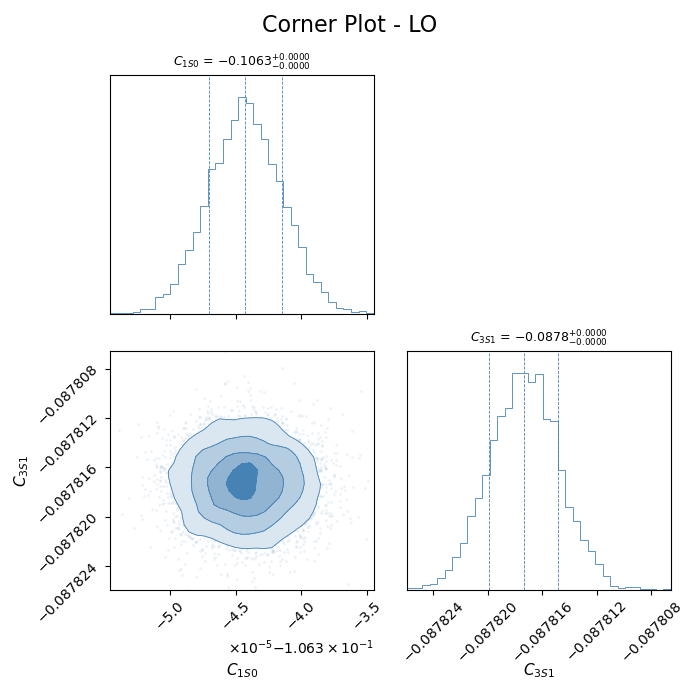

In [17]:
fig = plt.figure(figsize=(7, 7))

corner_fig = corner.corner(
    LO_chain,
    labels=[r"$C_{1S0}$", r"$C_{3S1}$"],
    show_titles=True,
    title_fmt=".4f",
    title_kwargs={"fontsize": 9},
    fig=fig,
    bins=35,
    smooth=1,
    color="steelblue",
    use_math_text=True,
    quantiles=[0.16, 0.5, 0.84],
    label_kwargs={"fontsize": 11, "labelpad": 14},
    hist_kwargs={"linewidth": 0.6},
    contour_kwargs={"linewidths": 0.6},
    plot_contours=True,
    fill_contours=True,
    plot_density=True
)

# Assottiglia le linee verticali tratteggiate dei quantili
for ax in np.array(corner_fig.axes):
    for line in ax.lines:
        if line.get_linestyle() == "--":
            line.set_linewidth(0.6)

fig.suptitle("Corner Plot - LO", fontsize=16)
fig.tight_layout()

fig.savefig("figure/corner_LO.pdf", bbox_inches="tight")

plt.show()

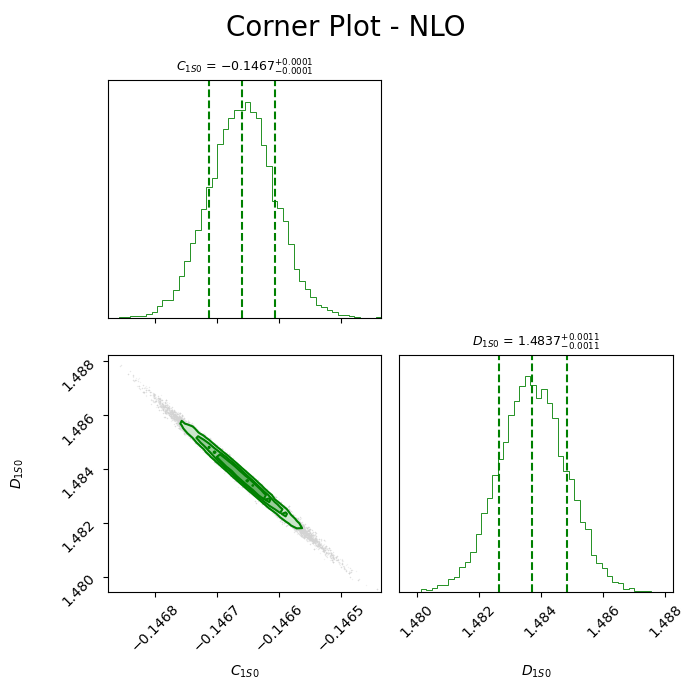

In [18]:
fig = plt.figure(figsize=(7, 7))

if NLO_chain_raw_2param.ndim == 3:
    # Burn-in sui passi, mantenendo la struttura (steps, walkers, ndim)
    burnin = int(0.5 * NLO_chain_raw_2param.shape[0])
    post_burnin_chain = NLO_chain_raw_2param[burnin:, :, :]

    n_steps, nwalkers, ndim = post_burnin_chain.shape
    best_fit = np.array([lec_values.nlo_lecs["C_1S0"], lec_values.nlo_lecs["D_1S0"]])[:ndim]

    # Filtro stile bayes_separato: tiene solo i walker vicini al best-fit
    distance_threshold = 1.0
    clean_chain = []
    removed_walkers = []

    for walker in range(nwalkers):
        single_walker_chain = post_burnin_chain[:, walker, :]
        distance_from_best_fit = np.linalg.norm(single_walker_chain - best_fit)

        if distance_from_best_fit < distance_threshold:
            clean_chain.append(single_walker_chain)
        else:
            removed_walkers.append(walker)

    clean_chain = np.array(clean_chain)

    if clean_chain.size == 0:
        print("Warning: nessun walker rimasto dopo il filtro; uso tutta la chain post-burnin.")
        nlo_samples = post_burnin_chain.reshape(-1, ndim)
    else:
        nlo_samples = clean_chain.reshape(-1, ndim)
else:
    nlo_samples = NLO_chain_2param[int(0.5 * len(NLO_chain_2param)):]
    ndim = nlo_samples.shape[1]

if ndim == len(param_names_NLO_1S0):
    nlo_labels = param_names_NLO_1S0
elif ndim == len(param_names_NLO_3S1):
    nlo_labels = param_names_NLO_3S1
else:
    nlo_labels = [f"param_{i}" for i in range(ndim)]

corner.corner(
    nlo_samples,
    labels=nlo_labels,
    show_titles=True,
    title_fmt=".4f",
    title_kwargs={"fontsize": 9},
    label_kwargs={"fontsize": 10, "labelpad": 14},
    fig=fig,
    bins=50,
    color="green",                    # Colore base per istogrammi e contorni
    data_kwargs={
        "color": "lightgray",         # Rende grigi i punti di dispersione
        "alpha": 0.3,                 # Li rende semitrasparenti
        "ms": 1.0             # Li rende più piccoli e delicati
    },
    verbose=False,
    use_math_text=False,
    quantiles=[0.16, 0.5, 0.84],
    hist_kwargs={"linewidth": 0.6},
    plot_contours=True,
    fill_contours=True,
    plot_density=True
)

fig.suptitle("Corner Plot - NLO ", fontsize=20)
fig.tight_layout()

fig.savefig("figure/corner_NLO_1S0.pdf", bbox_inches="tight")
plt.show()

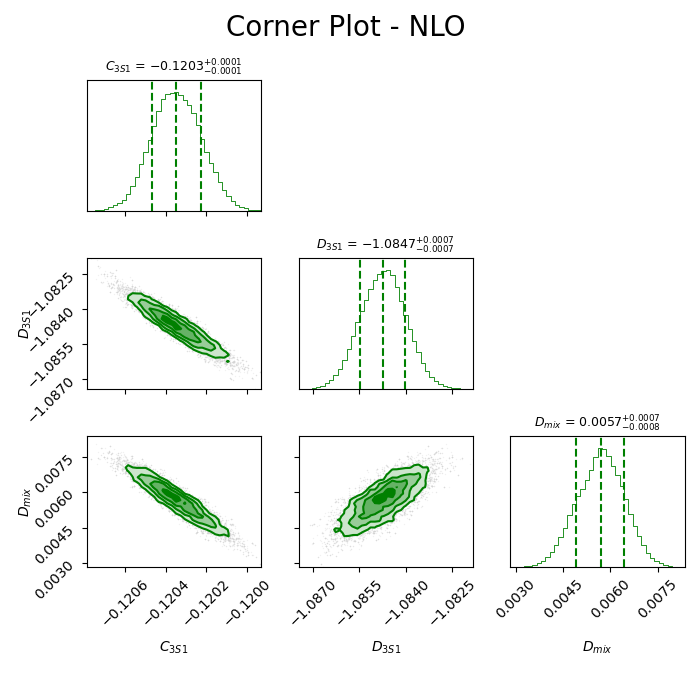

In [20]:
fig = plt.figure(figsize=(7, 7))

if NLO_chain_raw_3param.ndim == 3:
    # Burn-in sui passi, mantenendo la struttura (steps, walkers, ndim)
    burnin = int(0.5 * NLO_chain_raw_3param.shape[0])
    post_burnin_chain = NLO_chain_raw_3param[burnin:, :, :]

    n_steps, nwalkers, ndim = post_burnin_chain.shape
    best_fit = np.array([lec_values.nlo_lecs["C_3S1"], lec_values.nlo_lecs["D_3S1"], lec_values.nlo_lecs["D_3S1-3D1"]])[:ndim]

    # Filtro stile bayes_separato: tiene solo i walker vicini al best-fit
    distance_threshold = 1.0
    clean_chain = []
    removed_walkers = []

    for walker in range(nwalkers):
        single_walker_chain = post_burnin_chain[:, walker, :]
        distance_from_best_fit = np.linalg.norm(single_walker_chain - best_fit)

        if distance_from_best_fit < distance_threshold:
            clean_chain.append(single_walker_chain)
        else:
            removed_walkers.append(walker)

    clean_chain = np.array(clean_chain)

    if clean_chain.size == 0:
        print("Warning: nessun walker rimasto dopo il filtro; uso tutta la chain post-burnin.")
        nlo_samples = post_burnin_chain.reshape(-1, ndim)
    else:
        nlo_samples = clean_chain.reshape(-1, ndim)
else:
    nlo_samples = NLO_chain_3param[int(0.5 * len(NLO_chain_3param)):]
    ndim = nlo_samples.shape[1]

if ndim == len(param_names_NLO_1S0):
    nlo_labels = param_names_NLO_1S0
elif ndim == len(param_names_NLO_3S1):
    nlo_labels = param_names_NLO_3S1
else:
    nlo_labels = [f"param_{i}" for i in range(ndim)]

corner.corner(
    nlo_samples,
    labels=nlo_labels,
    show_titles=True,
    title_fmt=".4f",
    title_kwargs={"fontsize": 9},
    label_kwargs={"fontsize": 10, "labelpad": 14},
    fig=fig,
    bins=40,
    smooth1d=1,
    smooth=0.5,
    color="green",                    # Colore base per istogrammi e contorni
    data_kwargs={
        "color": "lightgray",         # Rende grigi i punti di dispersione
        "alpha": 0.3,                 # Li rende semitrasparenti
        "ms": 1.0             # Li rende più piccoli e delicati
    },
    verbose=False,
    use_math_text=False,
    quantiles=[0.16, 0.5, 0.84],
    hist_kwargs={"linewidth": 0.6},
    plot_contours=True,
    fill_contours=True,
    plot_density=True
)

# Sposta in basso i nomi dei parametri sull'ultima riga del corner plot.
axes_grid = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    axes_grid[-1, i].xaxis.set_label_coords(0.5, -0.55)

fig.suptitle("Corner Plot - NLO ", fontsize=20)
fig.tight_layout()

fig.savefig("figure/corner_NLO_3S1.pdf", bbox_inches="tight")
plt.show()

## Trace dei parametri

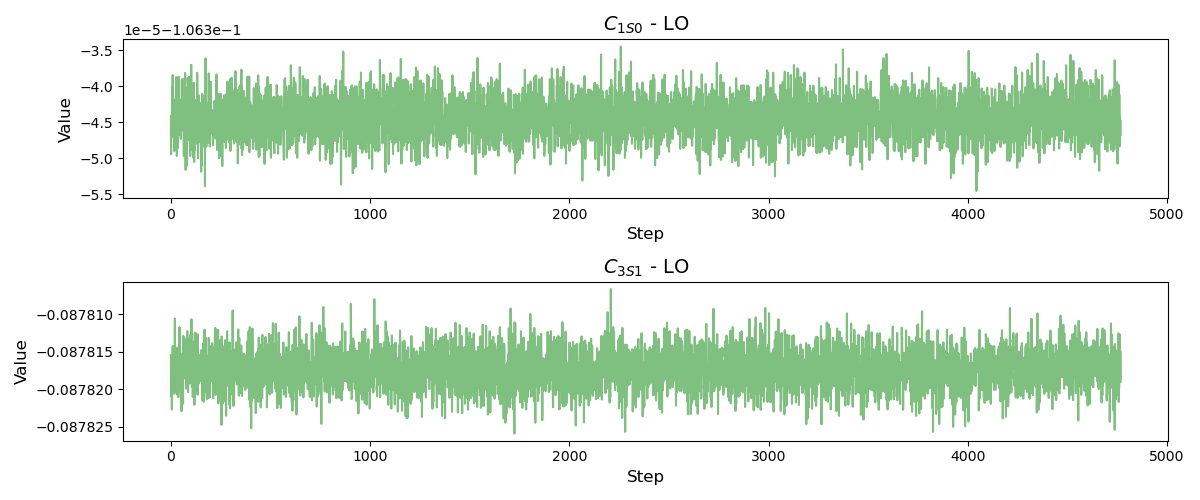

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5))

param1 = LO_chain[:, 0]
param2 = LO_chain[:, 1]

axes[0].plot(param1, color="green", alpha=0.5)
axes[0].set_title(r"$C_{1S0}$ - LO", fontsize=14)
axes[0].set_xlabel("Step", fontsize=12)
axes[0].set_ylabel("Value", fontsize=12)
axes[1].plot(param2, color="green", alpha=0.5)
axes[1].set_title(r"$C_{3S1}$ - LO", fontsize=14)
axes[1].set_xlabel("Step", fontsize=12)
axes[1].set_ylabel("Value", fontsize=12)
fig.tight_layout()
fig.savefig("figure/trace_LO.pdf", bbox_inches="tight")
plt.show()

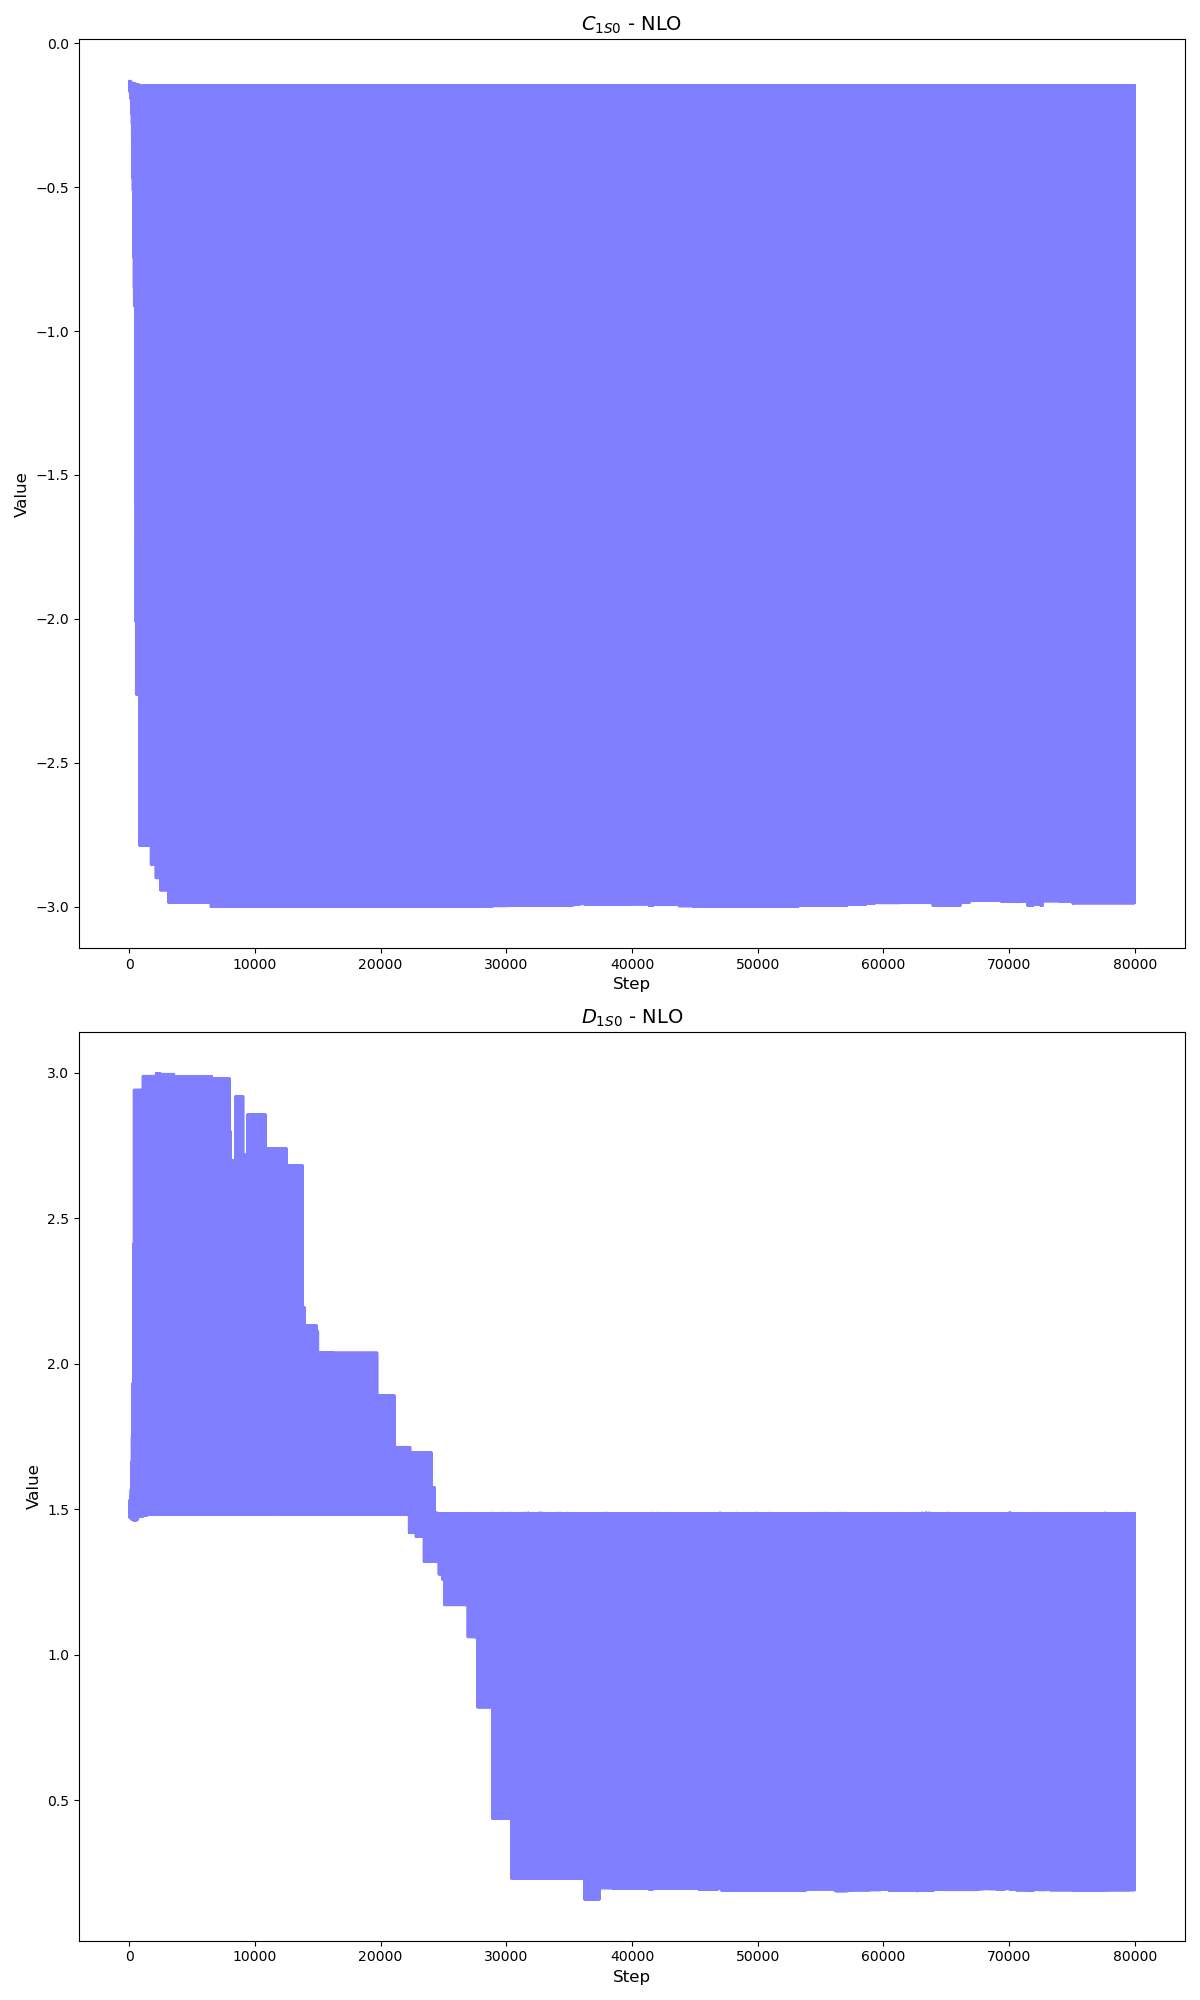

In [ ]:
fig, axes = plt.subplots(NLO_chain_2param.shape[1], 1, figsize=(12, 20))

params = [NLO_chain_2param[:, i] for i in range(NLO_chain_2param.shape[1])]

if NLO_chain_2param.shape[1] == len(param_names_NLO_1S0):
    param_names = param_names_NLO_1S0
elif NLO_chain_2param.shape[1] == len(param_names_NLO_3S1):
    param_names = param_names_NLO_3S1
else:
    param_names = [f"param_{i}" for i in range(NLO_chain_2param.shape[1])]

for idx, (p, n) in enumerate(zip(params, param_names)):
    axes[idx].plot(p, color="blue", alpha=0.5)
    axes[idx].set_title(f"{n} - NLO", fontsize=14)
    axes[idx].set_xlabel("Step", fontsize=12)
    axes[idx].set_ylabel("Value", fontsize=12)
fig.tight_layout()
fig.savefig("figure/trace_NLO.pdf", bbox_inches="tight")
plt.show()

## Confronto modello-dati

### Calcolo dei best fit ed errori sui parametri

In [21]:
best_params_LO = np.median(LO_chain, axis=0)
errors_LO = np.percentile(LO_chain, [16, 84], axis=0) - best_params_LO


best_params_NLO_2param = np.median(NLO_chain_2param[int(0.5*len(NLO_chain_2param)):], axis=0)
errors_NLO_2param = np.percentile(NLO_chain_2param[int(0.5*len(NLO_chain_2param)):], [16, 84], axis=0) - best_params_NLO_2param


best_params_NLO_3param = np.median(NLO_chain_3param[int(0.5*len(NLO_chain_3param)):], axis=0)
errors_NLO_3param = np.percentile(NLO_chain_3param[int(0.5*len(NLO_chain_3param)):], [16, 84], axis=0) - best_params_NLO_3param

### Inizializzazione nn_studio e import dei dati

In [22]:
# Caricamento dati Granada

T_Lab = granada.Tlabs

shift_1S0 = granada.delta_1S0
shift_1S0_error = granada.delta_1S0_errors

shift_3S1 = granada.delta_3S1
shift_3S1_error = granada.delta_3S1_errors

shift_3D1 = granada.delta_3D1
shift_3D1_error = granada.delta_3D1_errors

shift_mix = granada.delta_3E1
shift_mix_error = granada.delta_3E1_errors

experimental_shifts = {
    "shift_1S0": (shift_1S0, shift_1S0_error),
    "shift_3S1": (shift_3S1, shift_3S1_error),
    "shift_3D1": (shift_3D1, shift_3D1_error),
    "shift_mix": (shift_mix, shift_mix_error)
}


In [23]:
# Inizializzazione nn_studio

nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=30, mesh_type="gauleg_infinite")
nn.Tlabs = T_Lab

### Lookup dei canali e calcolo phase shifts

In [24]:
# lookup dei canali di interesse

_, channel_1S0 = nn.lookup_channel_idx(l=0,ll=0,s=0,j=0) # Il canale 1S0 è il primo orbitale anti-legante, in cui gli spin sono accoppiati (chn_idx=0)
_, channel_3S1 = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1) # Il canale 3S1 è quello del ground state del deutone, in cui si accoppiano 3S1-3D1 (chn_idx=4)
_, channel_3D1 = nn.lookup_channel_idx(l=2,ll=0,s=1,j=1) # Il canale 3D1 è quello del ground state del deutone, in cui si accoppiano 3S1-3D1 (chn_idx=5)
_, channel_mix = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1) # Il canale di miscela 3S1-3D1 è quello del ground state del deutone, in cui si accoppiano 3S1-3D1 (chn_idx=4)


In [25]:
for i in channel_3S1[0]:
    print(i)

{'l': 0, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}
{'l': 0, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}
{'l': 2, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}
{'l': 2, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}


In [ ]:
def compute_phase_shifts(lecs, channel, model="LO", E_lambda=500.0):

    if model == "LO":
        lecs = {
            "C_1S0": lecs[0],
            "C_3S1": lecs[1]
        }

    elif model == "NLO":
        # Supporta NLO completo (5 parametri) e fit separati (2 parametri 1S0, 3 parametri 3S1)
        if len(lecs) == 2:
            lecs = {
                "C_1S0": lecs[0],
                "D_1S0": lecs[1],
                "C_3S1": lec_values.nlo_lecs["C_3S1"],
                "D_3S1": lec_values.nlo_lecs["D_3S1"],
                "D_mix": lec_values.nlo_lecs["D_3S1-3D1"]
            }
        elif len(lecs) == 3:
            lecs = {
                "C_1S0": lec_values.nlo_lecs["C_1S0"],
                "D_1S0": lec_values.nlo_lecs["D_1S0"],
                "C_3S1": lecs[0],
                "D_3S1": lecs[1],
                "D_mix": lecs[2]
            }
        elif len(lecs) == 5:
            lecs = {
                "C_1S0": lecs[0],
                "C_3S1": lecs[1],
                "D_1S0": lecs[2],
                "D_3S1": lecs[3],
                "D_mix": lecs[4]
            }
        else:
            raise ValueError(f"NLO richiede 2, 3 o 5 parametri, ricevuti {len(lecs)}")

    else:
        raise NotImplementedError("Modello non implementato")
    
    nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=30, mesh_type="gauleg_infinite")
    nn.Tlabs = T_Lab

    nn.V = chiral_potential.two_nucleon_potential(model, Lambda=E_lambda)
    nn.lecs = lecs
    nn.compute_Tmtx(channel, verbose=False)

    return nn.phase_shifts


### Confronto LO vs dati

In [29]:
# Creazione figure per confronto LO vs dati e NLO vs dati, con residui negli stessi plot di NLO (per ora abbiamo solo 1S0)
with plt.ioff():

    fig_LO_1S0, ax_LO_1S0 = plt.subplots(1, 1)
    fig_LO_1S0_residuals, ax_LO_1S0_residuals = plt.subplots(1, 1)

    fig_LO_3S1, ax_LO_3S1 = plt.subplots(1, 1)
    fig_LO_3S1_residuals, ax_LO_3S1_residuals = plt.subplots(1, 1)

    # Titoli e etichette assi
    ax_LO_1S0.set_title("LO - Canale 1S0", fontsize=14)
    ax_LO_1S0.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_LO_1S0.set_ylabel(r"Phase Shift [deg]", fontsize=12)

    ax_LO_3S1.set_title("LO - Canale 3S1", fontsize=14)
    ax_LO_3S1.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_LO_3S1.set_ylabel(r"Phase Shift [deg]", fontsize=12)

    ax_LO_1S0_residuals.set_title("LO - Residui 1S0", fontsize=14)
    ax_LO_1S0_residuals.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_LO_1S0_residuals.set_ylabel(r"Residuals [deg]", fontsize=12)

    ax_LO_3S1_residuals.set_title("LO - Residui 3S1", fontsize=14)
    ax_LO_3S1_residuals.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_LO_3S1_residuals.set_ylabel(r"Residuals [deg]", fontsize=12)

    # calcolo dei phase shifts e residui per LO
    phase_shifts_LO_1S0 = compute_phase_shifts(best_params_LO, channel_1S0, model="LO")[0]
    phase_shifts_LO_1S0_max = compute_phase_shifts(best_params_LO + errors_LO[1], channel_1S0, model="LO")[0]
    phase_shifts_LO_1S0_min = compute_phase_shifts(best_params_LO + errors_LO[0], channel_1S0, model="LO")[0]
    residuals_LO_1S0 = phase_shifts_LO_1S0 - experimental_shifts["shift_1S0"][0]
    phase_shifts_LO_3S1 = compute_phase_shifts(best_params_LO, channel_3S1, model="LO")[0][:,0]
    phase_shifts_LO_3S1_max = compute_phase_shifts(best_params_LO + errors_LO[1], channel_3S1, model="LO")[0][:,0]
    phase_shifts_LO_3S1_min = compute_phase_shifts(best_params_LO + errors_LO[0], channel_3S1, model="LO")[0][:,0]
    residuals_LO_3S1 = phase_shifts_LO_3S1 - experimental_shifts["shift_3S1"][0]

    # plot dei phase shifts e residui per LO
    ax_LO_1S0.errorbar(T_Lab, experimental_shifts["shift_1S0"][0], yerr=experimental_shifts["shift_1S0"][1], fmt="o", label="Dati Granada - 1S0", color="black", markersize=5)
    ax_LO_1S0.plot(T_Lab, phase_shifts_LO_1S0, label="Modello - LO", color="blue", marker="o", markersize=5)
    ax_LO_1S0.fill_between(T_Lab, phase_shifts_LO_1S0_min, phase_shifts_LO_1S0_max, color="blue", alpha=0.3, label="Uncertainty - LO")

    ax_LO_1S0_residuals.plot(T_Lab, residuals_LO_1S0, label="Residui - LO", color="red", marker="o", markersize=5)
    ax_LO_1S0_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)

    ax_LO_3S1.errorbar(T_Lab, experimental_shifts["shift_3S1"][0], yerr=experimental_shifts["shift_3S1"][1], fmt="o", label="Dati Granada - 3S1", color="black", markersize=5)
    ax_LO_3S1.plot(T_Lab, phase_shifts_LO_3S1, label="Modello - LO", color="green", marker="o", markersize=5)
    ax_LO_3S1.fill_between(T_Lab, phase_shifts_LO_3S1_min, phase_shifts_LO_3S1_max, color="green", alpha=0.3, label="Uncertainty - LO")

    ax_LO_3S1_residuals.plot(T_Lab, residuals_LO_3S1, label="Residui - LO", color="red", marker="o", markersize=5)
    ax_LO_3S1_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)

    LO_figs = [fig_LO_1S0, fig_LO_3S1, fig_LO_1S0_residuals, fig_LO_3S1_residuals]

    # tight layout su tutto
    [fig.tight_layout() for fig in LO_figs]

    # salvataggio figure
    fig_names = ["LO_1S0", "LO_3S1", "LO_1S0_residuals", "LO_3S1_residuals"]
    [fig.savefig(f"figure/{name}.pdf", bbox_inches="tight") for fig, name in zip(LO_figs, fig_names)]





/tmp/ipykernel_14482/249461383.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig_LO_1S0, ax_LO_1S0 = plt.subplots(1, 1)


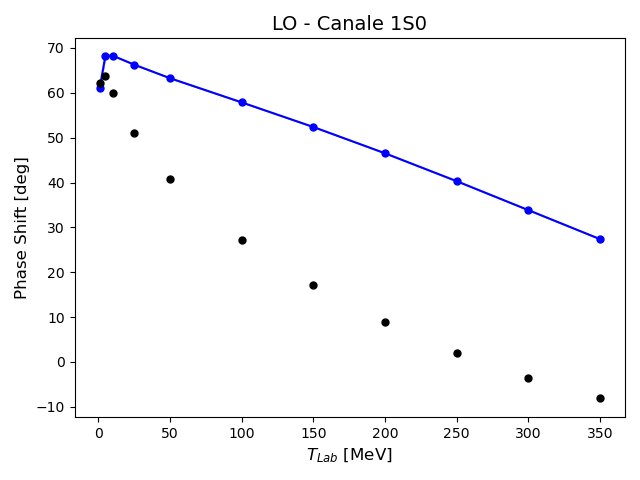

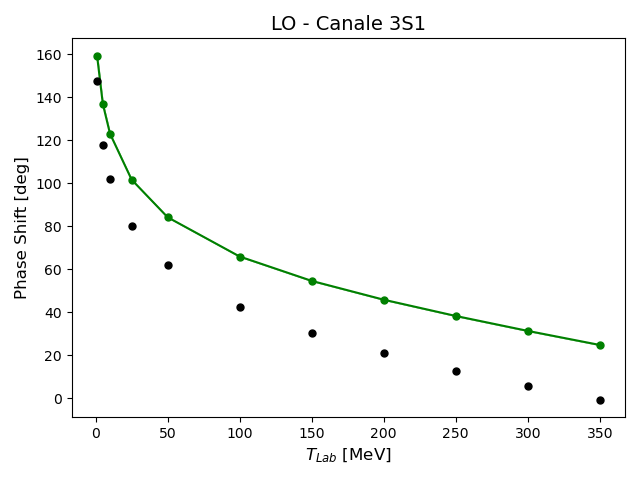

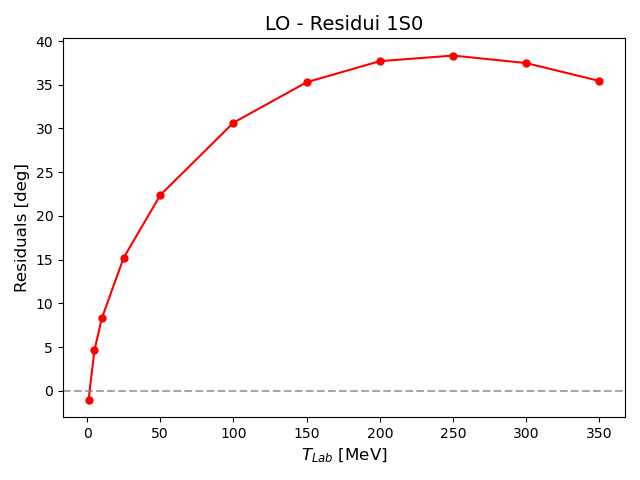

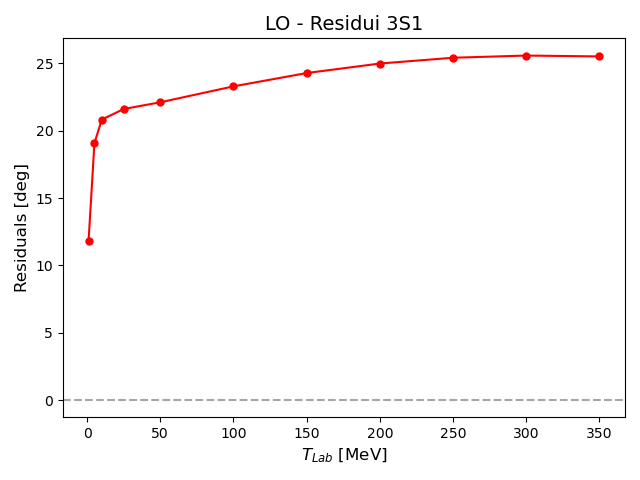

[None, None, None, None]

In [30]:
[fig.show() for fig in LO_figs]

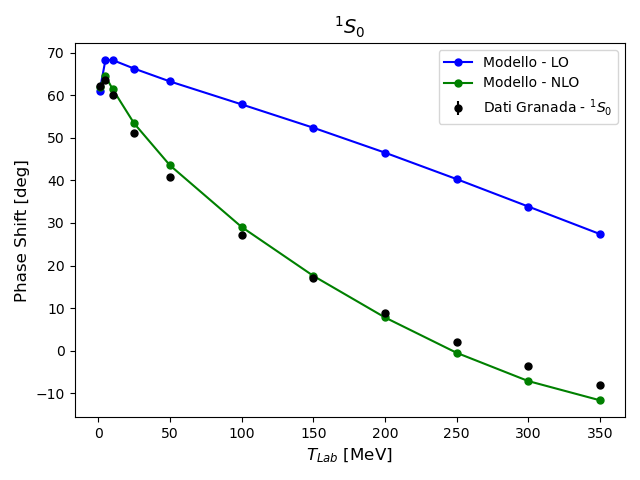

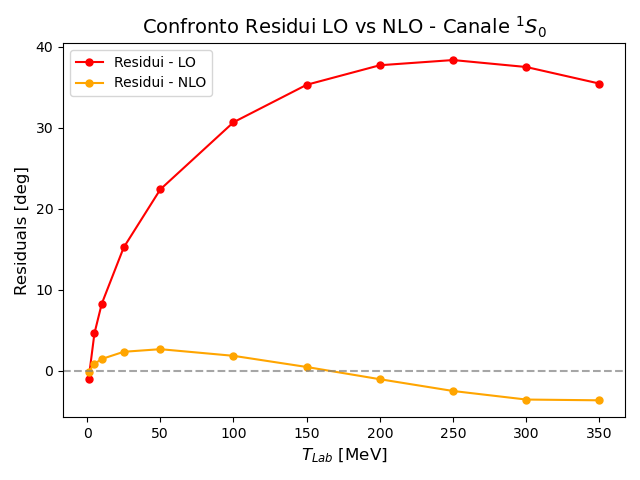

In [32]:
# creo grafico phase shift per 1s0 usando i nostri risultati LO e NLO, con residui nello stesso plot per confronto diretto
with plt.ioff():
    
    fig_1S0, ax_1S0 = plt.subplots(1, 1)
    fig_1S0_residuals, ax_1S0_residuals = plt.subplots(1, 1)

    # Titoli e etichette assi
    ax_1S0.set_title("$^1S_0$", fontsize=14)
    ax_1S0.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_1S0.set_ylabel(r"Phase Shift [deg]", fontsize=12)

    ax_1S0_residuals.set_title("Confronto Residui LO vs NLO - Canale $^1S_0$", fontsize=14)
    ax_1S0_residuals.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_1S0_residuals.set_ylabel(r"Residuals [deg]", fontsize=12)

    # calcolo dei phase shifts e residui per NLO
    phase_shifts_NLO_1S0 = compute_phase_shifts(best_params_NLO_2param, channel_1S0, model="NLO")[0]
    phase_shifts_NLO_1S0_max = compute_phase_shifts(best_params_NLO_2param + errors_NLO_2param[1], channel_1S0, model="NLO")[0]
    phase_shifts_NLO_1S0_min = compute_phase_shifts(best_params_NLO_2param + errors_NLO_2param[0], channel_1S0, model="NLO")[0]
    residuals_NLO_1S0 = phase_shifts_NLO_1S0 - experimental_shifts["shift_1S0"][0]

    # plot dei phase shifts e residui per NLO
    ax_1S0.errorbar(T_Lab, experimental_shifts["shift_1S0"][0], yerr=experimental_shifts["shift_1S0"][1], fmt="o", label="Dati Granada - $^1S_0$", color="black", markersize=5)
    ax_1S0.plot(T_Lab, phase_shifts_LO_1S0, label="Modello - LO", color="blue",marker="o", markersize=5)
    ax_1S0.plot(T_Lab, phase_shifts_NLO_1S0, label="Modello - NLO", color="green",marker="o", markersize=5)
    ax_1S0.legend()
    ax_1S0_residuals.plot(T_Lab, residuals_LO_1S0, label="Residui - LO", color="red", marker="o", markersize=5)
    ax_1S0_residuals.plot(T_Lab, residuals_NLO_1S0, label="Residui - NLO", color="orange", marker="o", markersize=5)
    ax_1S0_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax_1S0_residuals.legend()
    
    fig_1S0.tight_layout()
    fig_1S0_residuals.tight_layout()
    fig_1S0.savefig("figure/1S0_comparison.pdf", bbox_inches="tight")
    fig_1S0_residuals.savefig("figure/1S0_residuals_comparison.pdf", bbox_inches="tight")
    fig_1S0.show()
    fig_1S0_residuals.show()


In [33]:
# creo grafico phase shift per 3s1 usando i nostri risultati LO e NLO, con residui nello stesso plot per confronto diretto
with plt.ioff():
    
    fig_3S1, ax_3S1 = plt.subplots(1, 1)
    fig_3S1_residuals, ax_3S1_residuals = plt.subplots(1, 1)

    # Titoli e etichette assi
    ax_3S1.set_title("$^3S_1$", fontsize=14)
    ax_3S1.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_3S1.set_ylabel(r"Phase Shift [deg]", fontsize=12)

    ax_3S1_residuals.set_title("Confronto Residui LO vs NLO - Canale $^3S_1$", fontsize=14)
    ax_3S1_residuals.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_3S1_residuals.set_ylabel(r"Residuals [deg]", fontsize=12)

    # calcolo dei phase shifts e residui per NLO
    phase_shifts_NLO_3S1 = compute_phase_shifts(best_params_NLO_3param, channel_3S1, model="NLO")[0][:,0]
    phase_shifts_NLO_3S1_max = compute_phase_shifts(best_params_NLO_3param + errors_NLO_3param[1], channel_3S1, model="NLO")[0][:,0]
    phase_shifts_NLO_3S1_min = compute_phase_shifts(best_params_NLO_3param + errors_NLO_3param[0], channel_3S1, model="NLO")[0][:,0]
    residuals_NLO_3S1 = phase_shifts_NLO_3S1 - experimental_shifts["shift_3S1"][0]

    # plot dei phase shifts e residui per NLO
    ax_3S1.errorbar(T_Lab, experimental_shifts["shift_3S1"][0], yerr=experimental_shifts["shift_3S1"][1], fmt="o", label="Dati Granada - $^3S_1$", color="black", markersize=5)
    ax_3S1.plot(T_Lab, phase_shifts_LO_3S1, label="Modello - LO", color="blue", marker="o", markersize=5)
    ax_3S1.plot(T_Lab, phase_shifts_NLO_3S1, label="Modello - NLO", color="green", marker="o", markersize=5)
    ax_3S1.legend()
    ax_3S1_residuals.plot(T_Lab, residuals_LO_3S1, label="Residui - LO", color="red", marker="o", markersize=5)
    ax_3S1_residuals.plot(T_Lab, residuals_NLO_3S1, label="Residui - NLO", color="orange", marker="o", markersize=5)
    ax_3S1_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax_3S1_residuals.legend()
    
    fig_3S1.tight_layout()
    fig_3S1_residuals.tight_layout()
    fig_3S1.savefig("figure/3S1_comparison.pdf", bbox_inches="tight")
    fig_3S1_residuals.savefig("figure/3S1_residuals_comparison.pdf", bbox_inches="tight")
    fig_3S1.show()
    fig_3S1_residuals.show()    
    

ValueError: NLO richiede 2 o 5 parametri, ricevuti 3